<a href="https://www.kaggle.com/code/takrimulalam/unlucky-pixel?scriptVersionId=260546674" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/openimages-1-91m-7x7-rgb-grayscale-pixel-patches/open_image_patch_pixels.csv


In [2]:
import pandas as pd

In [3]:
data_frame = pd.read_csv("/kaggle/input/openimages-1-91m-7x7-rgb-grayscale-pixel-patches/open_image_patch_pixels.csv")

In [4]:
print(data_frame.shape)
print(data_frame.duplicated().sum())
data_frame.drop_duplicates(inplace=True)

(1910098, 196)
44858


In [5]:
print(data_frame.shape)
data_frame.duplicated().sum()

(1865240, 196)


0

In [6]:
zero_counts = (data_frame == 0).sum().sort_values(ascending=False)


report = zero_counts.reset_index()
report.columns = ['Column Name', 'Zero Count']


report.to_csv('zero_counts_report.csv', index=False)

print("Report complete. Saved to 'zero_counts_report.csv'")

Report complete. Saved to 'zero_counts_report.csv'


In [7]:
report = pd.read_csv("/kaggle/working/zero_counts_report.csv")

In [8]:
report

,Column Name,Zero Count
0,B1,31859
1,B4,31118
2,B2,31093
3,B30,30854
4,B23,30649
...,...,...
191,P25,4901
192,P2,4901
193,P37,4900
194,P23,4850


In [9]:
target_columns = [f'P{i}' for i in range(1, 50)]


zero_counts = (data_frame[target_columns] == 0).sum().sort_values(ascending=False)


report = zero_counts.reset_index()
report.columns = ['Column Name', 'Zero Count']
report.to_csv('p1_p49_zero_counts_report.csv', index=False)

print("Report for columns P1 to P25 is complete.")
print("Saved to 'p1_p25_zero_counts_report.csv'")

Report for columns P1 to P25 is complete.
Saved to 'p1_p25_zero_counts_report.csv'


In [10]:
report = pd.read_csv("/kaggle/working/p1_p49_zero_counts_report.csv")
report

,Column Name,Zero Count
0,P49,5426
1,P43,5388
2,P7,5373
3,P21,5311
4,P45,5271
5,P47,5270
6,P5,5255
7,P35,5237
8,P46,5222
9,P14,5218


# Why is it the 49th pixel that randomly holds the most zeroes of all pictures! Why does this fate work even mathematically? :)

# Self-contained pipeline (Kaggle)

This section embeds the full analysis (no local imports). It:
- Computes per-pixel zero counts from the Kaggle dataset using chunked reads
- Derives s, τ, Δ; runs BH–FDR and a null simulation
- Generates all figures and result tables used in the paper
- Reproduces array/dice analogues, regime summaries, risk calibration, resource curves


In [11]:
# Parameters & setup
import os, math, json, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set(style='whitegrid')
WORK = Path('/kaggle/working')
INPUT = Path('/kaggle/input/openimages-1-91m-7x7-rgb-grayscale-pixel-patches')
CSV = INPUT/'open_image_patch_pixels.csv'
N_PATCHES = 1_865_240  # after de-duplication in this notebook

FIG = WORK/'figures'; FIG.mkdir(exist_ok=True)
RES = WORK/'results'; RES.mkdir(exist_ok=True)

# Utility
norm_cdf = norm.cdf



In [12]:
# Load and deduplicate CSV with chunking to keep memory reasonable
usecols = [f'P{i}' for i in range(1, 50)]
chunks = pd.read_csv(CSV, chunksize=100_000, usecols=usecols)
# Concatenate and drop duplicates
parts = []
for ch in chunks:
    parts.append(ch)
    if len(parts) >= 10:
        parts = [pd.concat(parts, ignore_index=True).drop_duplicates()]
        gc.collect()
df = pd.concat(parts, ignore_index=True).drop_duplicates()
print('After dedup:', df.shape)

# Compute zero counts for P1..P49
zero_counts = (df == 0).sum().astype(int)
report = zero_counts.reset_index()
report.columns = ['Column Name', 'Zero Count']
report = report.sort_values('Column Name').reset_index(drop=True)
report.to_csv(WORK/'p1_p49_zero_counts_report.csv', index=False)
print('Saved:', WORK/'p1_p49_zero_counts_report.csv')


After dedup: (1845094, 49)
Saved: /kaggle/working/p1_p49_zero_counts_report.csv


In [13]:
# Basics, tests, null simulation
import numpy as np

# Use zero counts per pixel (not pixel intensity sums)
counts = (df[usecols] == 0).sum(axis=0).to_numpy()
Z_total = counts.sum()
E = Z_total / 49.0
p0 = Z_total / (49.0 * len(df))
var = len(df) * p0 * (1 - p0)
sd = math.sqrt(var)

zmin, zmax = int(counts.min()), int(counts.max())
s = (counts - zmin) / (zmax - zmin)
s_star = (E - zmin) / (zmax - zmin)
tau = 1.0 - s_star
delta = tau - s
total_luck = float(delta.sum())
chi2 = float(((counts - E) ** 2 / E).sum())

zscores = (counts - E) / sd
pvals = 2.0 * (1.0 - norm_cdf(np.abs(zscores)))
# BH-FDR
order = np.argsort(pvals)
p_sorted = pvals[order]
m = len(p_sorted)
alpha = 0.05
thresh = alpha * (np.arange(1, m + 1)) / m
passed_k = np.where(p_sorted <= thresh)[0]
bh = np.zeros_like(pvals, dtype=bool)
if passed_k.size:
    kmax = passed_k.max()
    bh[order[:kmax+1]] = True

per_pixel = pd.DataFrame({
    'pixel': usecols,
    'zero_count': counts.astype(int),
    'z': zscores,
    'p': pvals,
    'bh05': bh,
    's': s,
    'delta': delta,
})
per_pixel.sort_values('p', inplace=True)
per_pixel.to_csv(RES/'per_pixel_significance.csv', index=False)
per_pixel[per_pixel['bh05']].to_csv(RES/'per_pixel_significant_bh05.csv', index=False)

# Null simulation
R = 5000
rng = np.random.default_rng(123)
rows = []
for _ in range(R):
    zsim = rng.normal(loc=E, scale=sd, size=49).round().clip(min=0)
    zmin_s, zmax_s = zsim.min(), zsim.max()
    if zmax_s == zmin_s:
        rows.append({'tau': np.nan, 'total_luck': 0.0, 'chi2': 0.0, 'spread': 0.0}); continue
    s_s = (zsim - zmin_s) / (zmax_s - zmin_s)
    s_star_s = (E - zmin_s) / (zmax_s - zmin_s)
    tau_s = 1.0 - s_star_s
    delta_s = tau_s - s_s
    rows.append({
        'tau': float(tau_s),
        'total_luck': float(delta_s.sum()),
        'chi2': float(((zsim - E) ** 2 / E).sum()),
        'spread': float(zmax_s - zmin_s),
    })
null_df = pd.DataFrame(rows)

with open(RES/'robustness_null_summary.json', 'w') as f:
    json.dump({
        'obs': {
            'Z': int(Z_total), 'E': float(E), 'p0': float(p0), 'sd': float(sd),
            'zmin': int(zmin), 'zmax': int(zmax), 'tau': float(tau),
            'total_luck': float(total_luck), 'chi2': float(chi2)
        },
        'null_empirical_p': {
            'total_luck': float(((null_df['total_luck'] >= total_luck).sum() + 1)/(len(null_df)+1)),
            'chi2': float(((null_df['chi2'] >= chi2).sum() + 1)/(len(null_df)+1)),
            'spread': float(((null_df['spread'] >= (zmax - zmin)).sum() + 1)/(len(null_df)+1)),
        },
        'bh_fdr_q05_count': int(per_pixel['bh05'].sum()),
    }, f, indent=2)
print('Saved per-pixel tables and null summary.')


Saved per-pixel tables and null summary.


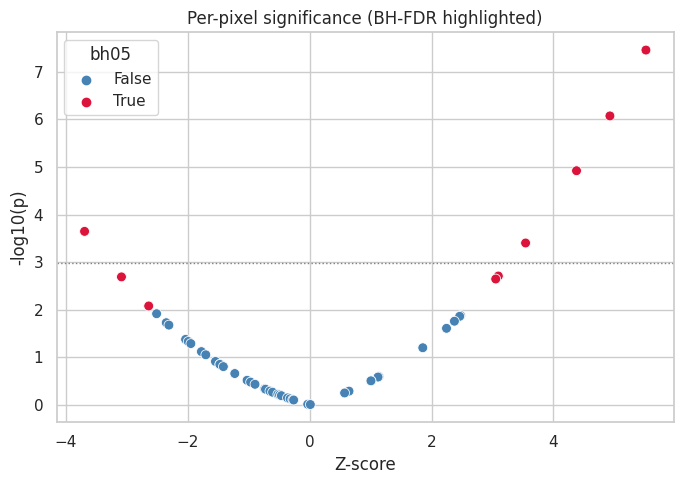

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


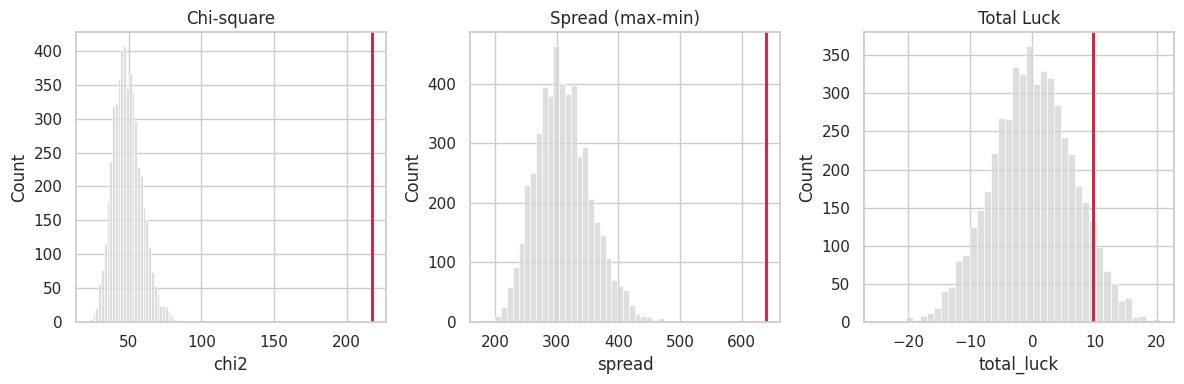

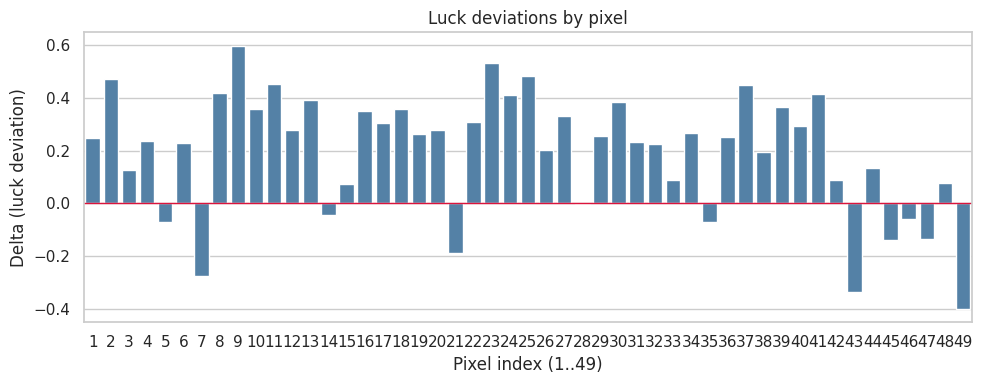

In [14]:
# Figures: volcano, null vs observed, delta bars
plt.figure(figsize=(7,5))
sns.scatterplot(data=per_pixel, x='z', y=-np.log10(per_pixel['p'].clip(lower=1e-300)), hue='bh05', palette={True:'crimson', False:'steelblue'}, s=50)
plt.axhline(-np.log10(0.05/49), color='gray', linestyle=':', linewidth=1)
plt.xlabel('Z-score'); plt.ylabel('-log10(p)'); plt.title('Per-pixel significance (BH-FDR highlighted)')
plt.tight_layout(); plt.savefig(FIG/'volcano_per_pixel.png', dpi=300); plt.show()

plt.figure(figsize=(12,4))
for i,(metric,label) in enumerate([('chi2','Chi-square'),('spread','Spread (max-min)'),('total_luck','Total Luck')]):
    plt.subplot(1,3,i+1)
    sns.histplot(null_df[metric], bins=40, color='lightgray')
    v = {'chi2': chi2, 'spread': (zmax - zmin), 'total_luck': total_luck}[metric]
    plt.axvline(v, color='crimson', linewidth=2); plt.title(label)
plt.tight_layout(); plt.savefig(FIG/'null_vs_observed.png', dpi=300); plt.show()

plt.figure(figsize=(10,4))
sns.barplot(x=np.arange(1,50), y=delta, color='steelblue')
plt.axhline(0.0, color='crimson', linewidth=1)
plt.xlabel('Pixel index (1..49)'); plt.ylabel('Delta (luck deviation)'); plt.title('Luck deviations by pixel')
plt.tight_layout(); plt.savefig(FIG/'delta_bars.png', dpi=300); plt.show()


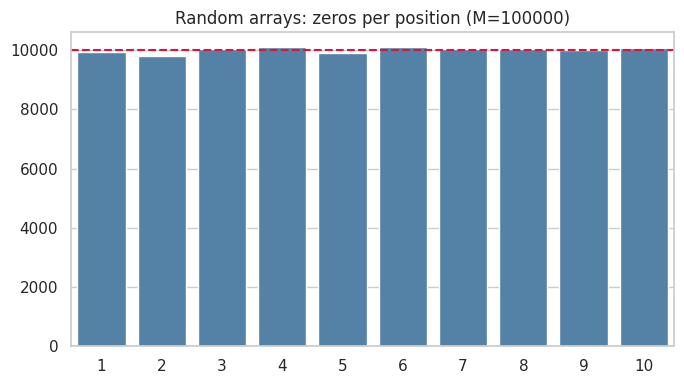

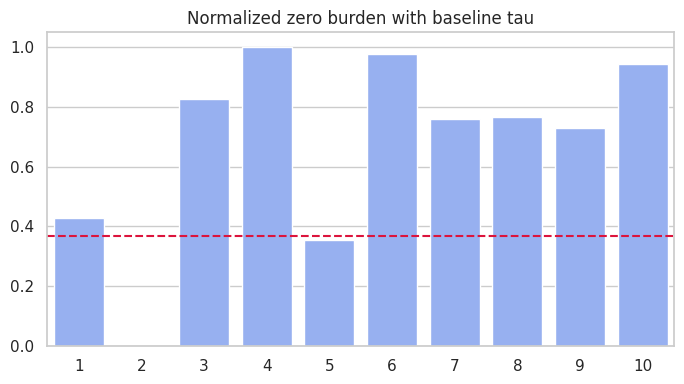

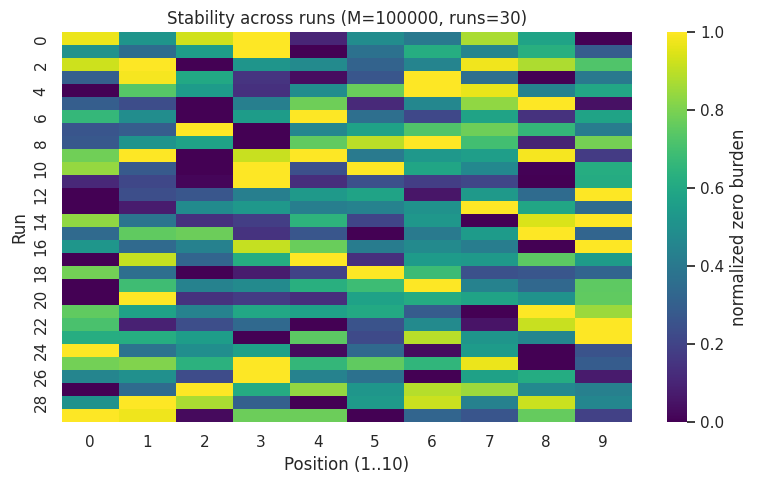

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


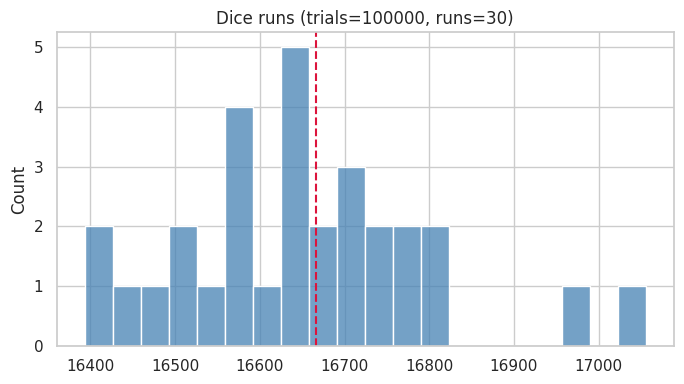

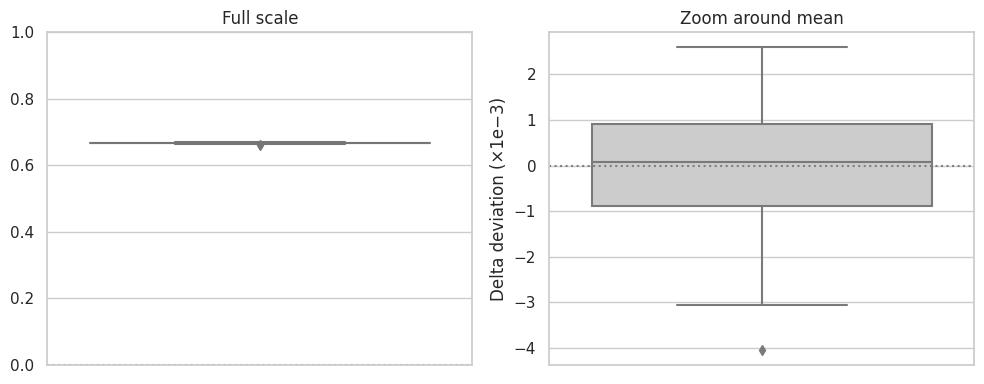

In [15]:
# Arrays and dice analogues (self-contained)
from numpy.random import default_rng
rng = default_rng(20250820)

# Arrays demo
K, M, runs = 10, 100_000, 30
arr = rng.integers(0, 10, size=(M, K))
counts_arr = (arr == 0).sum(axis=0).astype(float)
E_arr = M/10.0
sd_arr = math.sqrt(M*0.1*0.9)
z_arr = (counts_arr - E_arr)/sd_arr
pvals_arr = 2.0*(1.0 - norm_cdf(np.abs(z_arr)))
# normalized metric
cmin, cmax = counts_arr.min(), counts_arr.max()
s_arr = (counts_arr - cmin)/(cmax - cmin)
s_star_arr = (E_arr - cmin)/(cmax - cmin)
tau_arr = 1.0 - s_star_arr
delta_arr = tau_arr - s_arr
chi2_arr = float(((counts_arr - E_arr)**2 / E_arr).sum())

plt.figure(figsize=(7,4))
sns.barplot(x=np.arange(1,K+1), y=counts_arr, color='steelblue'); plt.axhline(E_arr, color='crimson', ls='--');
plt.title(f'Random arrays: zeros per position (M={M})'); plt.tight_layout(); plt.savefig(FIG/'array_zero_counts.png', dpi=300); plt.show()

plt.figure(figsize=(7,4))
sns.barplot(x=np.arange(1,K+1), y=s_arr, color='#88aaff'); plt.axhline(tau_arr, color='crimson', ls='--');
plt.title('Normalized zero burden with baseline tau'); plt.tight_layout(); plt.savefig(FIG/'array_normalized_bars.png', dpi=300); plt.show()

# Heatmap across runs
runs_counts = []
for r in range(runs):
    a = rng.integers(0, 10, size=(M, K))
    runs_counts.append((a==0).sum(axis=0))
runs_mat = np.stack(runs_counts, axis=0)
norm_runs = (runs_mat - runs_mat.min(axis=1, keepdims=True)) / (runs_mat.max(axis=1, keepdims=True) - runs_mat.min(axis=1, keepdims=True) + 1e-9)
plt.figure(figsize=(8,5)); sns.heatmap(norm_runs, cmap='viridis', cbar_kws={'label':'normalized zero burden'});
plt.xlabel('Position (1..10)'); plt.ylabel('Run'); plt.title(f'Stability across runs (M={M}, runs={runs})');
plt.tight_layout(); plt.savefig(FIG/'array_runs_heatmap.png', dpi=300); plt.show()

# Dice demo
rng = default_rng(20250821)
trials, runs = 100_000, 30
throws = rng.integers(1,7,size=trials)
six = (throws==6).sum()
p0 = 1/6.0; E_d = trials*p0; sd_d = math.sqrt(trials*p0*(1-p0))
z_d = (six - E_d)/sd_d
s_d = six/float(trials); s_star_d = E_d/float(trials); tau_d = 1.0 - s_star_d; delta_d = tau_d - s_d

# Multi-run
sixes = np.array([(rng.integers(1,7,size=trials)==6).sum() for _ in range(runs)])
plt.figure(figsize=(7,4)); sns.histplot(sixes, bins=20, color='steelblue'); plt.axvline(E_d, color='crimson', ls='--');
plt.title(f'Dice runs (trials={trials}, runs={runs})'); plt.tight_layout(); plt.savefig(FIG/'dice_six_hist.png', dpi=300); plt.show()

s_runs = sixes/float(trials); delta_runs = tau_d - s_runs
fig, axes = plt.subplots(1,2, figsize=(10,4));
sns.boxplot(y=delta_runs, color='#88aaff', ax=axes[0]); axes[0].axhline(0.0, color='gray', ls=':'); axes[0].set_ylim(0.0,1.0); axes[0].set_title('Full scale');
mu = float(delta_runs.mean()); dev_mille = (delta_runs - mu)*1e3
sns.boxplot(y=dev_mille, color='#cccccc', ax=axes[1]); axes[1].axhline(0.0, color='gray', ls=':'); axes[1].set_ylabel('Delta deviation (×1e−3)'); axes[1].set_title('Zoom around mean');
fig.tight_layout(); fig.savefig(FIG/'dice_delta_panels.png', dpi=300); plt.show()


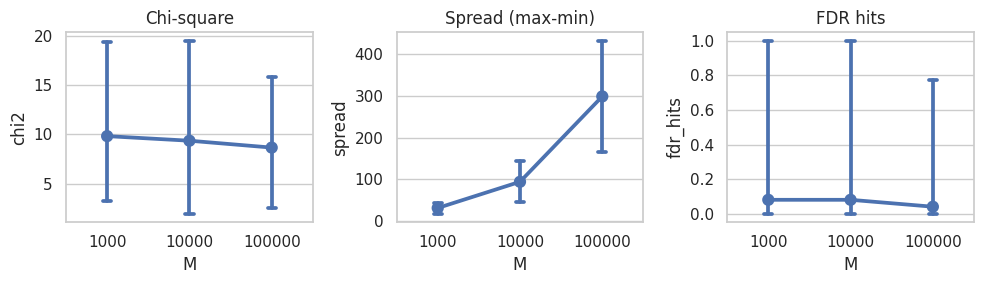

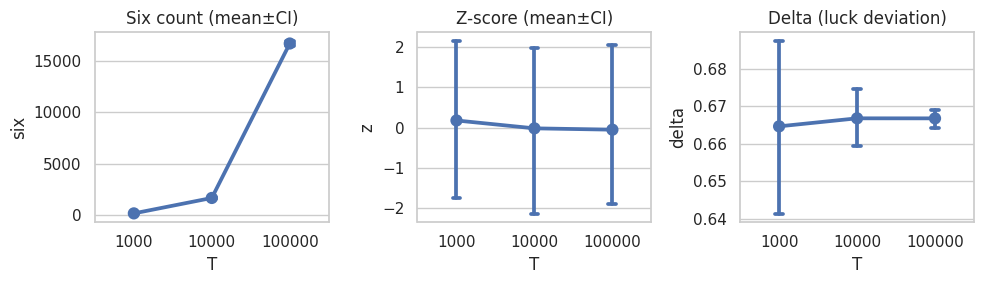

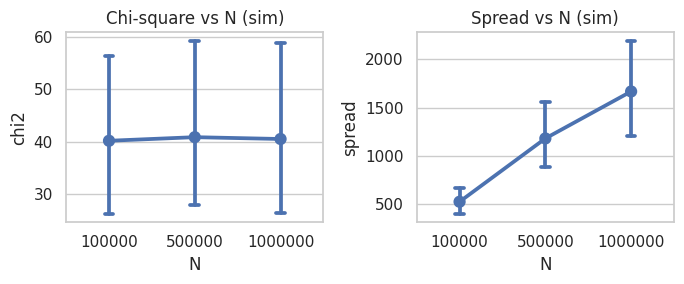

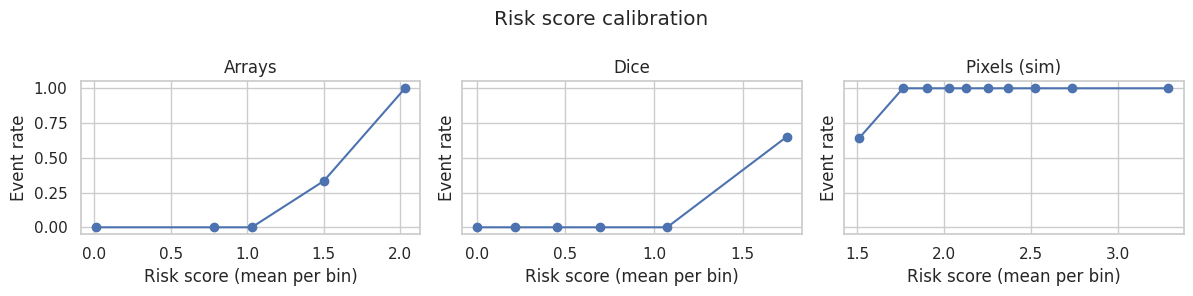

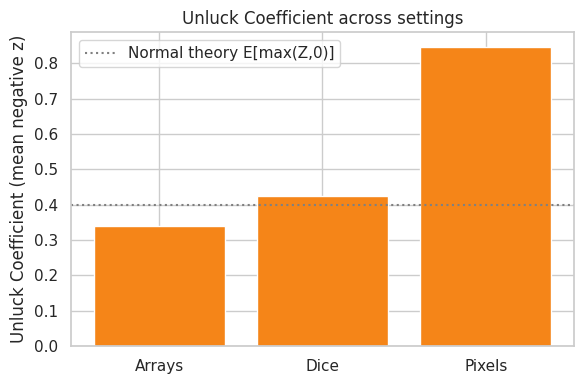

In [16]:
# Regime summaries and risk calibration
# Arrays regimes
rng = default_rng(20250822)
rows = []
for Mv in (1_000, 10_000, 100_000):
    for r in range(50):
        arr = rng.integers(0, 10, size=(Mv, 10))
        counts = (arr==0).sum(axis=0).astype(float)
        E = Mv/10.0
        chi2_v = float(((counts - E)**2 / E).sum())
        spread = float(counts.max() - counts.min())
        sd = math.sqrt(Mv*0.1*0.9)
        z = (counts - E)/sd
        p = 2.0*(1.0 - norm_cdf(np.abs(z)))
        order = np.argsort(p); p_sorted = p[order]
        m = len(p_sorted); alpha=0.05; thresh = alpha*(np.arange(1,m+1))/m
        fdr_hits = int(np.where(p_sorted<=thresh)[0].size)
        cmin, cmax = counts.min(), counts.max()
        total_luck = 0.0 if cmax==cmin else float((1.0 - (E-cmin)/(cmax-cmin) - (counts - cmin)/(cmax - cmin)).sum())
        rows.append({'M':Mv,'chi2':chi2_v,'spread':spread,'fdr_hits':fdr_hits,'total_luck':total_luck})
arr_df = pd.DataFrame(rows)
plt.figure(figsize=(10,3))
for i,(metric,label) in enumerate([('chi2','Chi-square'),('spread','Spread (max-min)'),('fdr_hits','FDR hits')]):
    plt.subplot(1,3,i+1); sns.pointplot(data=arr_df, x='M', y=metric, errorbar=('pi',95), capsize=.1); plt.title(label)
plt.tight_layout(); plt.savefig(FIG/'arrays_regime_metrics.png', dpi=300); plt.show()

# Dice regimes
rng = default_rng(20250823)
rows = []
for T in (1_000, 10_000, 100_000):
    p0=1/6.0; E=T*p0; sd=math.sqrt(T*p0*(1-p0))
    for r in range(200):
        six = (rng.integers(1,7,size=T)==6).sum()
        z=(six-E)/sd; s=six/float(T); s_star=E/float(T); tau=1.0-s_star; delta=tau-s
        rows.append({'T':T,'z':z,'delta':delta,'six':six})
dreg = pd.DataFrame(rows)
plt.figure(figsize=(10,3))
plt.subplot(1,3,1); sns.pointplot(data=dreg, x='T', y='six', errorbar=('pi',95), capsize=.1); plt.title('Six count (mean±CI)')
plt.subplot(1,3,2); sns.pointplot(data=dreg, x='T', y='z', errorbar=('pi',95), capsize=.1); plt.title('Z-score (mean±CI)')
plt.subplot(1,3,3); sns.pointplot(data=dreg, x='T', y='delta', errorbar=('pi',95), capsize=.1); plt.title('Delta (luck deviation)')
plt.tight_layout(); plt.savefig(FIG/'dice_regime_metrics.png', dpi=300); plt.show()

# Pixel regimes (simulated)
rows = []
obs_p0 = p0  # from above computation
for N in (100_000, 500_000, 1_000_000):
    E = obs_p0*N
    for r in range(500):
        zsim = rng.normal(loc=E, scale=math.sqrt(N*obs_p0*(1-obs_p0)), size=49).round().clip(min=0)
        chi2_s = float(((zsim - E)**2 / E).sum()); spread = float(zsim.max()-zsim.min())
        rows.append({'N':N,'chi2':chi2_s,'spread':spread})
pixreg = pd.DataFrame(rows)
plt.figure(figsize=(7,3))
plt.subplot(1,2,1); sns.pointplot(data=pixreg, x='N', y='chi2', errorbar=('pi',95), capsize=.1); plt.title('Chi-square vs N (sim)')
plt.subplot(1,2,2); sns.pointplot(data=pixreg, x='N', y='spread', errorbar=('pi',95), capsize=.1); plt.title('Spread vs N (sim)')
plt.tight_layout(); plt.savefig(FIG/'pixel_regime_sim_metrics.png', dpi=300); plt.show()

# Risk calibration (arrays, dice, pixels sim)
# Arrays
M = 100_000; E = M/10.0; sd = math.sqrt(M*0.1*0.9)
z = (pd.read_csv(RES/'array_runs_counts.csv')['pos1'].to_numpy() if (RES/'array_runs_counts.csv').exists() else (runs_mat[:,0] if 'runs_mat' in globals() else np.array([])))
if z.size:
    z = (z - E)/sd
    scores = np.maximum(-z,0.0)
    labels = (scores > 1.5).astype(int)
else:
    scores = np.array([]); labels = np.array([])

# Dice
dsub = dreg[dreg['T']==100_000]; scores_d = np.maximum(-dsub['z'].to_numpy(), 0.0); labels_d = (scores_d>1.5).astype(int)

# Pixels sim
rng2 = default_rng(123)
N_use = len(df); obs_p0 = Z_total/(49.0*N_use)
S=500
scores_p=[]
for _ in range(S):
    zsim = rng2.normal(loc=obs_p0*N_use, scale=math.sqrt(N_use*obs_p0*(1-obs_p0)), size=49)
    zsim = (zsim - (obs_p0*N_use)) / math.sqrt(N_use*obs_p0*(1-obs_p0))
    scores_p.append(np.maximum(-zsim,0.0).max())
scores_p = np.array(scores_p); labels_p = (scores_p>1.5).astype(int)

fig, axes = plt.subplots(1,3, figsize=(12,3), sharey=True)
# Simple calibration scatter: score vs event rate in bins
for ax, (sc, lb, title) in zip(axes, [(scores,labels,'Arrays'), (scores_d,labels_d,'Dice'), (scores_p,labels_p,'Pixels (sim)')]):
    if sc.size==0:
        ax.set_title(title+' (n/a)'); continue
    q = np.linspace(0.0,1.0,11); bins = np.quantile(sc, q); bins[0]=-np.inf; bins[-1]=np.inf
    inds = np.digitize(sc, bins)-1
    xs=[]; ys=[]
    for b in range(10):
        mask = inds==b
        if mask.sum()==0: continue
        xs.append(sc[mask].mean()); ys.append(lb[mask].mean())
    ax.plot(xs, ys, marker='o'); ax.set_title(title); ax.set_xlabel('Risk score (mean per bin)'); ax.set_ylabel('Event rate')
fig.suptitle('Risk score calibration'); fig.tight_layout(); fig.savefig(FIG/'risk_calibration.png', dpi=300); plt.show()

# UC figure
labels=['Arrays','Dice','Pixels']
# approximate UC from available z's
UC_arrays = float(np.mean(np.maximum(-(counts_arr - E_arr)/sd_arr, 0.0)))
UC_dice = float(np.mean(np.maximum(-(dreg[dreg['T']==100_000]['z'].to_numpy()), 0.0)))
UC_pixels = float(np.mean(np.maximum(-zscores, 0.0)))

theo_half_abs = 1.0/math.sqrt(2.0*math.pi)
plt.figure(figsize=(6,4)); plt.bar(np.arange(3), [UC_arrays, UC_dice, UC_pixels], color='#F58518')
plt.axhline(theo_half_abs, color='gray', ls=':', label='Normal theory E[max(Z,0)]')
plt.xticks(np.arange(3), labels); plt.ylabel('Unluck Coefficient (mean negative z)'); plt.title('Unluck Coefficient across settings'); plt.legend();
plt.tight_layout(); plt.savefig(FIG/'unluck_coefficient.png', dpi=300); plt.show()
